# Predicting 30-Day Hospital Readmission in Patients with Diabetes

### A Clinical Data Science Project

**Author:** Mohammad Abu Rabia

## Project Overview

Hospital readmission is an important clinical and healthcare-system outcome. Identifying patients at increased risk of early readmission may support future risk-stratification strategies and targeted follow-up.

This project explores whether routinely collected clinical and hospitalization data can help identify patients with diabetes who are at increased risk of hospital readmission within 30 days.

The analysis combines clinical data exploration, cohort refinement, preprocessing, and supervised machine-learning models.

## Research Question

**Can routinely collected clinical and hospitalization data identify patients with diabetes who are at increased risk of hospital readmission within 30 days?**

## Dataset

The project uses the **Diabetes 130-US Hospitals for Years 1999–2008** dataset from the UCI Machine Learning Repository.

The original dataset contains:

- 101,766 hospital encounters
- 50 original variables
- Data collected from 130 U.S. hospitals
- Demographic, diagnostic, medication, laboratory, and healthcare-utilization information

The primary outcome is hospital readmission within 30 days.

## Analytical Workflow

1. Data understanding and quality assessment
2. Definition of the 30-day readmission outcome
3. Missing-data analysis
4. Exploratory data analysis
5. Clinical review and cohort refinement
6. Train-test split and preprocessing
7. Majority-class baseline
8. Logistic Regression
9. Random Forest
10. Model evaluation and interpretation
11. Limitations and potential next steps

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path = r"C:\Users\User\Downloads\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [3]:
print(df["readmitted"].value_counts())

print("\nPercentages:")
print(df["readmitted"].value_counts(normalize=True) * 100)

NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64

Percentages:
NO     53.911916
>30    34.928169
<30    11.159916
Name: readmitted, dtype: float64


In [4]:
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30d"].value_counts())

print("\n30-day readmission rate:")
print(df["readmitted_30d"].mean() * 100)

0    90409
1    11357
Name: readmitted_30d, dtype: int64

30-day readmission rate:
11.159915885462727


In [5]:
df = df.replace("?", np.nan)

missing = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing[missing > 0].head(20)

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

In [6]:
print(df["readmitted"].value_counts())

print("\nPercentages:")
print((df["readmitted"].value_counts(normalize=True) * 100).round(2))

NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64

Percentages:
NO     53.91
>30    34.93
<30    11.16
Name: readmitted, dtype: float64


In [7]:
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30d"].value_counts())

print("\n30-day readmission rate:")
print(f"{df['readmitted_30d'].mean() * 100:.2f}%")

0    90409
1    11357
Name: readmitted_30d, dtype: int64

30-day readmission rate:
11.16%


In [8]:
df = df.replace("?", np.nan)

missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(missing[missing > 0].round(2))

weight               96.86
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64


## Missing Data Assessment

Missing values in the original dataset are represented by `"?"` rather than standard null values.  
These values were converted to `NaN` before assessing data completeness.

The missing-data analysis identified:

- `weight`: 96.86% missing
- `medical_specialty`: 49.08% missing
- `payer_code`: 39.56% missing
- `race`: 2.23% missing
- `diag_3`: 1.40% missing
- `diag_2`: 0.35% missing
- `diag_1`: 0.02% missing

Variables with extremely high missingness may provide limited reliable information for predictive modeling.  
The next step is to determine which variables should be excluded and how the remaining missing values should be handled.

## Feature Exclusion Based on Data Quality

Three variables were excluded because of substantial missingness:

- `weight` — 96.86% missing
- `medical_specialty` — 49.08% missing
- `payer_code` — 39.56% missing

`weight` contains insufficient observed data for reliable imputation.  
For this initial predictive analysis, `medical_specialty` and `payer_code` were also excluded to keep the preprocessing pipeline transparent and avoid introducing extensive assumptions about missing values.

In addition:

- `encounter_id` and `patient_nbr` are identifiers rather than clinical predictors and will not be used as model features.
- `readmitted` must be excluded from the predictors because the binary outcome `readmitted_30d` was derived directly from it. Including it would cause **target leakage**.

Variables with low levels of missingness, such as `race` and diagnosis fields, will be retained and handled separately.

In [9]:
columns_to_drop = [
    "encounter_id",
    "patient_nbr",
    "weight",
    "medical_specialty",
    "payer_code",
    "readmitted"
]

df_model = df.drop(columns=columns_to_drop).copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", df_model.shape)

Original dataset shape: (101766, 51)
Modeling dataset shape: (101766, 45)


## Remaining Missing Values

After excluding variables with substantial missingness and non-predictive identifiers, the remaining missing values are reassessed before preprocessing.

Variables with only a small proportion of missing observations may be retained rather than discarded, in order to preserve useful clinical information and avoid unnecessary loss of patient encounters.

## Remaining Missing Values

After excluding variables with substantial missingness and non-predictive identifiers, the remaining missing values are reassessed before preprocessing.

Variables with only a small proportion of missing observations may be retained rather than discarded, in order to preserve useful clinical information and avoid unnecessary loss of patient encounters.

In [10]:
remaining_missing = (
    df_model.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(
    remaining_missing[remaining_missing > 0]
    .round(2)
)

race      2.23
diag_3    1.40
diag_2    0.35
diag_1    0.02
dtype: float64


## Handling Remaining Missing Values

The remaining missing values occur in categorical variables and represent only a small proportion of the dataset:

- `race`: 2.23%
- `diag_3`: 1.40%
- `diag_2`: 0.35%
- `diag_1`: 0.02%

Rather than removing these encounters, missing values are assigned an `"Unknown"` category.

This approach preserves the full sample size and avoids making unsupported assumptions about the missing categorical values.

In [11]:
columns_with_missing = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

for column in columns_with_missing:
    df_model[column] = df_model[column].fillna("Unknown")

print("Total remaining missing values:")
print(df_model.isna().sum().sum())

Total remaining missing values:
0


## Exploratory Data Analysis

### 30-Day Readmission

The primary outcome of this project is hospital readmission within 30 days.

Understanding the distribution of the outcome is important before modeling, particularly because an imbalanced target can make accuracy alone a misleading evaluation metric.

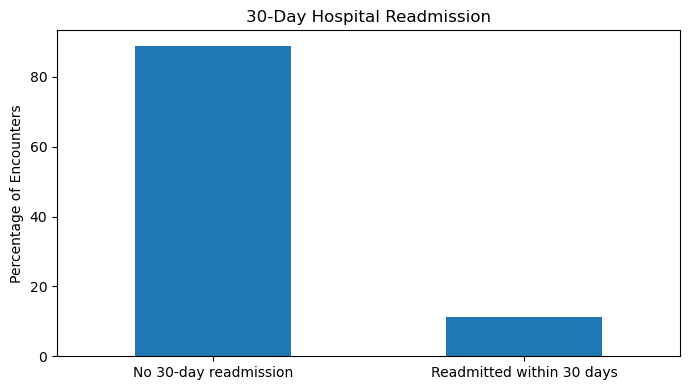

In [12]:
readmission_distribution = (
    df_model["readmitted_30d"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

readmission_distribution.index = [
    "No 30-day readmission",
    "Readmitted within 30 days"
]

readmission_distribution.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("30-Day Hospital Readmission")
plt.ylabel("Percentage of Encounters")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

Only **11.16%** of hospital encounters resulted in readmission within 30 days.

This indicates a substantial class imbalance. A model that predicts the majority class for every encounter could achieve relatively high accuracy while failing to identify patients who are actually readmitted.

Therefore, the predictive models will be evaluated using **precision, recall, F1-score and ROC-AUC**, in addition to accuracy.

### Readmission by Age Group

Age may be associated with hospital readmission risk because older patients often have greater clinical complexity, multimorbidity, and healthcare utilization.

The following analysis compares the observed 30-day readmission rate across the age groups available in the dataset.

In [13]:
age_readmission = (
    df_model
    .groupby("age")["readmitted_30d"]
    .agg(["mean", "count"])
)

age_readmission["readmission_rate"] = age_readmission["mean"] * 100

age_readmission[
    ["count", "readmission_rate"]
].round(2)

,count,readmission_rate
age,,
[0-10),161,1.86
[10-20),691,5.79
[20-30),1657,14.24
[30-40),3775,11.23
[40-50),9685,10.60
[50-60),17256,9.67
[60-70),22483,11.13
[70-80),26068,11.77
[80-90),17197,12.08


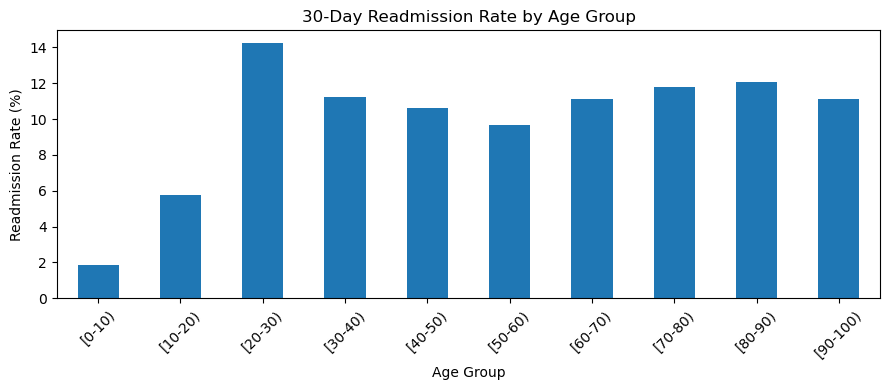

In [14]:
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)",
    "[40-50)", "[50-60)", "[60-70)", "[70-80)",
    "[80-90)", "[90-100)"
]

age_plot = (
    df_model
    .groupby("age")["readmitted_30d"]
    .mean()
    .reindex(age_order)
    .mul(100)
)

age_plot.plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The 30-day readmission rate varies across age groups, but the relationship is not strictly linear.

Among the larger adult age groups, readmission rates generally range from approximately 9.7% to 12.1%, with somewhat higher rates observed in the older age groups.

The [20–30) group shows a higher observed readmission rate (14.24%), but this group contains substantially fewer encounters than the older age groups. Therefore, this descriptive result should be interpreted cautiously.

These findings represent associations in the dataset and should not be interpreted as evidence that age itself causes hospital readmission.

### Previous Inpatient Visits and 30-Day Readmission

Previous hospital utilization may provide information about a patient's clinical complexity and healthcare needs.

The variable `number_inpatient` represents the number of inpatient visits recorded during the year preceding the current encounter.

The following analysis examines whether patients with more previous inpatient visits show different 30-day readmission rates.

In [15]:
inpatient_readmission = (
    df_model
    .groupby("number_inpatient")["readmitted_30d"]
    .agg(["count", "mean"])
)

inpatient_readmission["readmission_rate"] = (
    inpatient_readmission["mean"] * 100
)

inpatient_readmission[
    ["count", "readmission_rate"]
].head(15).round(2)

,count,readmission_rate
number_inpatient,,
0,67630,8.44
1,19521,12.92
2,7566,17.43
3,3411,20.29
4,1622,23.61
5,812,31.40
6,480,34.58
7,268,35.45
8,151,44.37


### Grouping Previous Inpatient Utilization

The raw data show a strong increase in observed 30-day readmission rates as the number of previous inpatient visits increases.

Because very high numbers of previous admissions occur in relatively few encounters, these values are grouped into a `5+` category for clearer and more stable visualization.

In [16]:
df_model["inpatient_group"] = df_model["number_inpatient"].apply(
    lambda x: str(x) if x < 5 else "5+"
)

inpatient_group_order = ["0", "1", "2", "3", "4", "5+"]

inpatient_group_summary = (
    df_model
    .groupby("inpatient_group")["readmitted_30d"]
    .agg(["count", "mean"])
    .reindex(inpatient_group_order)
)

inpatient_group_summary["readmission_rate"] = (
    inpatient_group_summary["mean"] * 100
)

inpatient_group_summary[
    ["count", "readmission_rate"]
].round(2)

,count,readmission_rate
inpatient_group,,
0,67630,8.44
1,19521,12.92
2,7566,17.43
3,3411,20.29
4,1622,23.61
5+,2016,36.41


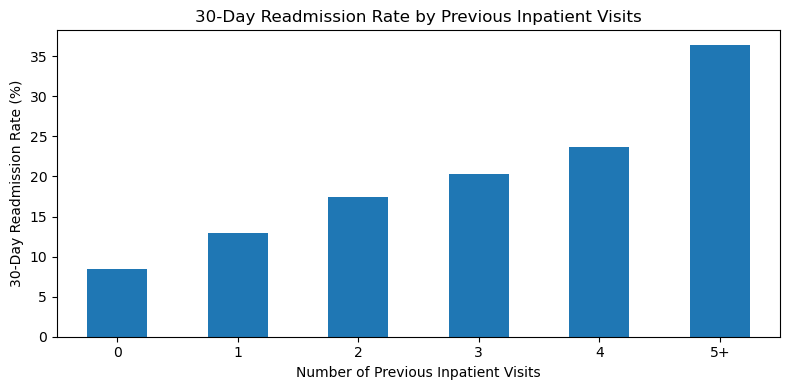

In [17]:
inpatient_group_summary["readmission_rate"].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("30-Day Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("30-Day Readmission Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

A clear positive association is observed between previous inpatient utilization and 30-day readmission.

The observed readmission rate increased from **8.44%** among encounters with no previous inpatient visits to **36.41%** among patients with five or more previous inpatient visits.

This suggests that prior inpatient utilization may be an important predictive feature for identifying patients at increased risk of early readmission.

However, this is a descriptive association and does not establish causality or demonstrate that previous hospitalization is an independent predictor after adjustment for other clinical factors.

### Length of Stay and 30-Day Readmission

Length of stay may reflect illness severity, treatment complexity, complications, or other clinical and operational factors.

The following analysis examines the observed 30-day readmission rate according to the number of days spent in the hospital during the index encounter.

In [18]:
los_readmission = (
    df_model
    .groupby("time_in_hospital")["readmitted_30d"]
    .agg(["count", "mean"])
)

los_readmission["readmission_rate"] = (
    los_readmission["mean"] * 100
)

los_readmission[
    ["count", "readmission_rate"]
].round(2)

,count,readmission_rate
time_in_hospital,,
1,14208,8.18
2,17224,9.94
3,17756,10.67
4,13924,11.81
5,9966,12.03
6,7539,12.59
7,5859,12.83
8,4391,14.23
9,3002,13.72


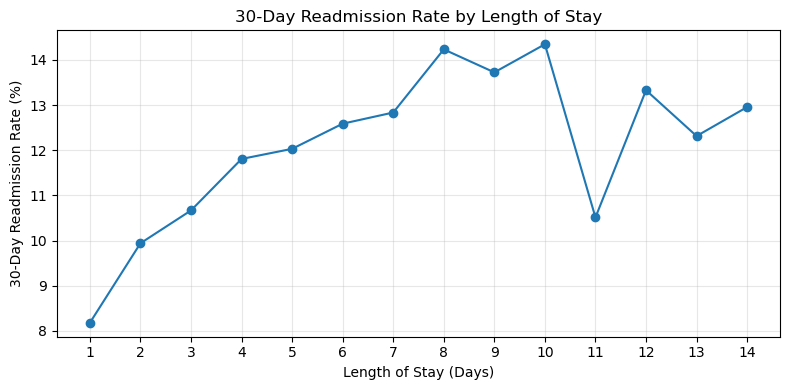

In [19]:
los_readmission["readmission_rate"].plot(
    kind="line",
    marker="o",
    figsize=(8, 4)
)

plt.title("30-Day Readmission Rate by Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("30-Day Readmission Rate (%)")
plt.xticks(range(1, 15))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The observed 30-day readmission rate generally increases across shorter-to-moderate lengths of stay.

Readmission increased from **8.18%** among one-day hospitalizations to approximately **14%** among several of the longer hospitalization groups.

However, the relationship is not strictly linear, particularly after approximately 10 days of hospitalization.

Length of stay may therefore contain useful predictive information, but the observed association should not be interpreted as causal. Longer hospitalization may also reflect differences in illness severity, complications, treatment complexity, or other patient characteristics.

> **Preliminary modeling note:**  
> The following models represent the initial analytical iteration. Model interpretation later identified a clinically important issue in the cohort definition. After reviewing discharge-disposition codes, death-related encounters were excluded and all models were retrained.
>
> **Only the results in the Final Modeling section should be considered the final reported model performance.**

## Predictive Modeling

The next stage evaluates whether routinely collected hospitalization and clinical variables can help identify encounters associated with 30-day readmission.

The dataset is imbalanced, with only 11.16% of encounters belonging to the positive class. Therefore, model performance will not be judged by accuracy alone.

The analysis will begin with an interpretable Logistic Regression baseline before comparing it with a nonlinear model.

In [20]:
df_model = df_model.drop(columns=["inpatient_group"])

print("Modeling dataset shape:", df_model.shape)

Modeling dataset shape: (101766, 45)


### Feature and Target Definition

The binary outcome `readmitted_30d` is separated from the predictor variables before model development.

- **Target = 1:** readmission within 30 days
- **Target = 0:** no readmission within 30 days

The original `readmitted` variable was previously removed because it directly contains the information used to construct the target and would therefore cause target leakage.

In [21]:
X = df_model.drop(columns=["readmitted_30d"])
y = df_model["readmitted_30d"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True).round(4))

Features shape: (101766, 44)
Target shape: (101766,)

Target distribution:
0    0.8884
1    0.1116
Name: readmitted_30d, dtype: float64


### Train-Test Split

The data are divided into training and test sets before preprocessing.

A stratified split is used to preserve the approximately 11.16% positive-class prevalence in both datasets.

The test set is kept separate from model development so that final performance can be evaluated on previously unseen encounters.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nPositive class rate:")
print("Train:", round(y_train.mean() * 100, 2), "%")
print("Test:", round(y_test.mean() * 100, 2), "%")

Training set: (81412, 44)
Test set: (20354, 44)

Positive class rate:
Train: 11.16 %
Test: 11.16 %


### Preprocessing Strategy

The dataset contains both numerical and categorical predictors.

To avoid data leakage, preprocessing is incorporated into a Scikit-learn pipeline and fitted using the training data only.

- Numerical variables will be standardized.
- Categorical variables will be transformed using one-hot encoding.
- Unknown categories encountered in the test set will be safely ignored.

In [23]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 11
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features: 33
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


### Preprocessing Pipeline

Numerical and categorical variables require different preprocessing steps.

A `ColumnTransformer` is used so that all transformations are learned from the training data and subsequently applied unchanged to the test data.

This design also makes the modeling workflow reproducible and reduces the risk of preprocessing-related data leakage.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


### Baseline Model

Because the dataset is imbalanced, a simple majority-class classifier provides an important reference point.

The baseline model always predicts the most frequent class: no readmission within 30 days.

Any predictive model developed later should demonstrate meaningful improvement over this trivial strategy, especially in its ability to identify the minority class.

In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Accuracy:",
      round(accuracy_score(y_test, baseline_preds), 4))

print("Baseline Precision:",
      round(precision_score(y_test, baseline_preds, zero_division=0), 4))

print("Baseline Recall:",
      round(recall_score(y_test, baseline_preds, zero_division=0), 4))

print("Baseline F1:",
      round(f1_score(y_test, baseline_preds, zero_division=0), 4))

print("Baseline ROC-AUC:",
      round(roc_auc_score(y_test, baseline_probs), 4))

Baseline Accuracy: 0.8884
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0
Baseline ROC-AUC: 0.5


### Baseline Interpretation

The majority-class baseline achieved an apparently high accuracy of **88.84%**.

However, it failed to identify any encounters resulting in 30-day readmission:

- Precision: 0.00
- Recall: 0.00
- F1-score: 0.00
- ROC-AUC: 0.50

This demonstrates why accuracy alone is inappropriate for evaluating this imbalanced clinical prediction problem.

A clinically useful model must provide meaningful discrimination and identify at least a proportion of patients who experience early readmission.

## Logistic Regression

Logistic Regression is used as the first predictive model because it provides a well-established and relatively interpretable baseline for binary classification.

Because only 11.16% of encounters belong to the positive class, the model uses balanced class weights so that errors involving the minority class receive greater importance during training.

All preprocessing remains inside the pipeline and is fitted only on the training data.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


### Logistic Regression Evaluation

The trained Logistic Regression model is now evaluated on the held-out test set.

Performance is assessed using multiple metrics because the outcome is highly imbalanced:

- **Accuracy** — overall proportion of correct predictions.
- **Precision** — among encounters predicted as 30-day readmissions, how many were actually readmitted.
- **Recall (Sensitivity)** — among encounters actually readmitted within 30 days, how many the model identified.
- **F1-score** — balance between precision and recall.
- **ROC-AUC** — ability of the model to discriminate between positive and negative encounters across classification thresholds.

For this clinical prediction problem, recall is particularly informative because a model with very low sensitivity would fail to identify many patients who experience early readmission.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logistic_preds = logistic_model.predict(X_test)
logistic_probs = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("---------------------------")

print("Accuracy:",
      round(accuracy_score(y_test, logistic_preds), 4))

print("Precision:",
      round(precision_score(y_test, logistic_preds), 4))

print("Recall:",
      round(recall_score(y_test, logistic_preds), 4))

print("F1-score:",
      round(f1_score(y_test, logistic_preds), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_test, logistic_probs), 4))

Logistic Regression Results
---------------------------
Accuracy: 0.6444
Precision: 0.1669
Recall: 0.5478
F1-score: 0.2558
ROC-AUC: 0.6422


### Logistic Regression Interpretation

The Logistic Regression model achieved:

- Accuracy: **64.44%**
- Precision: **16.69%**
- Recall (Sensitivity): **54.78%**
- F1-score: **25.58%**
- ROC-AUC: **0.642**

Compared with the majority-class baseline, the model sacrifices overall accuracy in exchange for substantially improved identification of patients who experience 30-day readmission.

The baseline achieved 88.84% accuracy but had **0% recall**, meaning that it failed to identify any positive cases.

In contrast, Logistic Regression identified approximately **54.8% of actual 30-day readmissions**.

However, the low precision indicates a substantial number of false-positive predictions. Therefore, this model should be interpreted as an exploratory predictive baseline rather than a clinically deployable prediction tool.

The ROC-AUC of 0.642 indicates modest discriminatory ability and suggests that additional feature engineering or alternative models may improve performance.

### Confusion Matrix

A confusion matrix provides a more clinically interpretable view of model performance by showing:

- True negatives
- False positives
- False negatives
- True positives

For this project, false negatives are particularly important because they represent patients who experienced 30-day readmission but were not identified by the model.

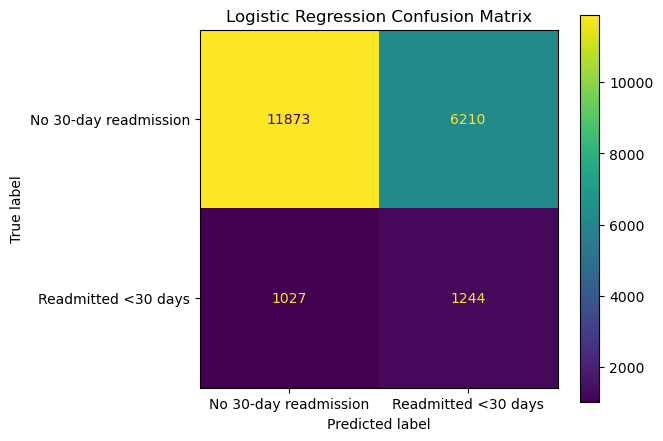

[[11873  6210]
 [ 1027  1244]]


In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, logistic_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No 30-day readmission",
        "Readmitted <30 days"
    ]
)

disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

print(cm)

### Confusion Matrix Interpretation

The Logistic Regression model correctly identified **1,244 of 2,271** encounters that resulted in readmission within 30 days, corresponding to a sensitivity (recall) of **54.78%**.

However, the model also generated **6,210 false-positive predictions**, which explains the relatively low precision of **16.69%**.

Additionally, **1,027 actual 30-day readmissions were missed** by the model.

This illustrates an important clinical trade-off: increasing sensitivity can help identify more potentially high-risk patients, but may also increase the number of patients incorrectly classified as high risk.

The model should therefore be considered an exploratory risk-stratification model rather than a clinical decision tool.

## Random Forest

A Random Forest classifier is evaluated as a nonlinear alternative to Logistic Regression.

Random Forest can capture nonlinear relationships and interactions between variables without requiring these relationships to be specified in advance.

Balanced class weights are used because 30-day readmission represents only 11.16% of encounters.

The model is evaluated on the same held-out test set to allow a fair comparison with Logistic Regression.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


### Random Forest Evaluation

The Random Forest model is evaluated on the same held-out test set used for Logistic Regression.

Using identical evaluation metrics allows direct comparison between the linear and nonlinear approaches.

Particular attention is given to recall, F1-score, and ROC-AUC because of the substantial class imbalance in the outcome.

In [30]:
rf_preds = random_forest_model.predict(X_test)
rf_probs = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")

print("Accuracy:",
      round(accuracy_score(y_test, rf_preds), 4))

print("Precision:",
      round(precision_score(y_test, rf_preds), 4))

print("Recall:",
      round(recall_score(y_test, rf_preds), 4))

print("F1-score:",
      round(f1_score(y_test, rf_preds), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_test, rf_probs), 4))

Random Forest Results
---------------------
Accuracy: 0.6333
Precision: 0.1687
Recall: 0.5821
F1-score: 0.2616
ROC-AUC: 0.6568


## Model Comparison

The two predictive models are compared with the majority-class baseline.

Because 30-day readmission is relatively uncommon, model selection is not based on accuracy alone. Greater emphasis is placed on recall, F1-score, and ROC-AUC.

Random Forest achieved the strongest overall discrimination and the highest sensitivity among the evaluated models.

In [31]:
model_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_preds),
        accuracy_score(y_test, logistic_preds),
        accuracy_score(y_test, rf_preds)
    ],
    "Precision": [
        precision_score(y_test, baseline_preds, zero_division=0),
        precision_score(y_test, logistic_preds),
        precision_score(y_test, rf_preds)
    ],
    "Recall": [
        recall_score(y_test, baseline_preds, zero_division=0),
        recall_score(y_test, logistic_preds),
        recall_score(y_test, rf_preds)
    ],
    "F1-score": [
        f1_score(y_test, baseline_preds, zero_division=0),
        f1_score(y_test, logistic_preds),
        f1_score(y_test, rf_preds)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_probs),
        roc_auc_score(y_test, logistic_probs),
        roc_auc_score(y_test, rf_probs)
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Majority Baseline,0.888,0.000,0.000,0.000,0.500
1,Logistic Regression,0.644,0.167,0.548,0.256,0.642
2,Random Forest,0.633,0.169,0.582,0.262,0.657


### Model Comparison Interpretation

The majority-class baseline achieved the highest apparent accuracy (88.84%) but failed to identify any 30-day readmissions.

Both machine-learning models provided meaningful discrimination compared with the baseline.

Random Forest produced the strongest overall results:

- Recall: **58.21%**
- F1-score: **26.16%**
- ROC-AUC: **0.657**

Compared with Logistic Regression, Random Forest identified a larger proportion of actual 30-day readmissions and achieved modest improvements in F1-score and ROC-AUC.

However, precision remained low (16.87%), indicating a high number of false-positive risk classifications.

These results suggest that routinely collected hospitalization data contain predictive information about early readmission, but the current models are not sufficiently accurate or validated for clinical deployment.

## Feature Importance

To better understand the Random Forest model, feature importance is extracted from the fitted pipeline.

Because categorical variables were one-hot encoded during preprocessing, the transformed feature names are retrieved directly from the preprocessing pipeline.

Feature importance indicates which variables contributed most to the model's predictions. It does not establish causality or prove that a feature is an independent clinical risk factor.

In [32]:
# Retrieve transformed feature names
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Retrieve Random Forest feature importances
feature_importances = (
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

,feature,importance
0,num__number_inpatient,0.164346
1,num__discharge_disposition_id,0.071174
2,num__number_emergency,0.051246
3,num__number_diagnoses,0.036905
4,num__num_medications,0.036753
5,num__time_in_hospital,0.036128
6,num__num_lab_procedures,0.020569
7,num__number_outpatient,0.020153
8,cat__diag_3_250,0.015542
9,cat__diag_2_250,0.014619


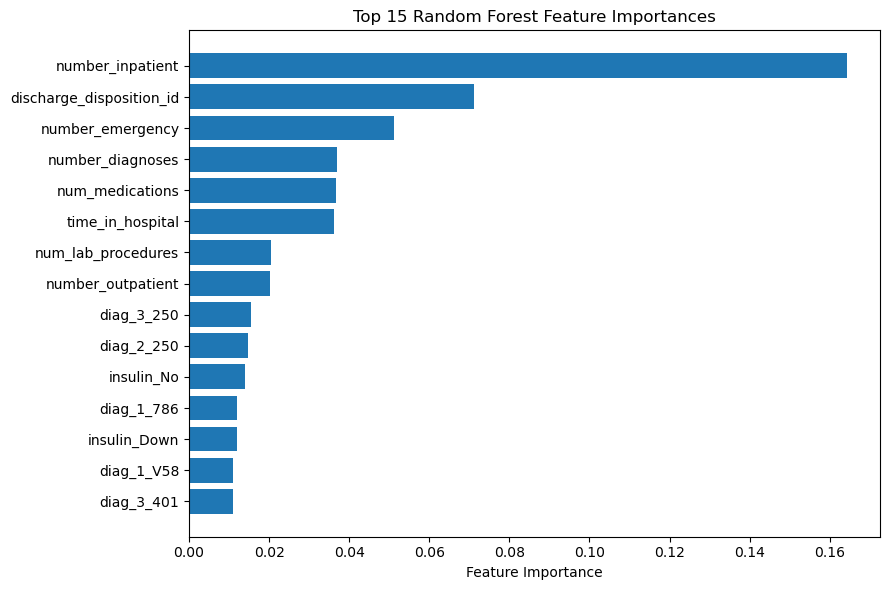

In [33]:
top_features = importance_df.head(15).copy()

# Remove preprocessing prefixes for cleaner labels
top_features["feature_clean"] = (
    top_features["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_features = top_features.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature_clean"],
    top_features["importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

`number_inpatient` was the most influential feature in the Random Forest model, with substantially greater importance than any other individual predictor.

This is consistent with the exploratory analysis, where the observed 30-day readmission rate increased from **8.44%** among encounters with no previous inpatient visits to **36.41%** among those with five or more previous inpatient visits.

Other influential features included:

- discharge disposition
- previous emergency utilization
- number of diagnoses
- number of medications
- length of stay
- number of laboratory procedures
- previous outpatient utilization

Several diagnosis and insulin-treatment categories also contributed to the model.

Feature importance reflects how the Random Forest used variables for prediction and should **not** be interpreted as evidence of causality or as proof that these variables are independent clinical risk factors.

## Clinical Validity Check: Discharge Disposition

`discharge_disposition_id` emerged as one of the most influential features in the Random Forest model.

Before interpreting this feature, it is important to examine its categories because some discharge outcomes may make subsequent hospital readmission impossible or clinically inappropriate for inclusion in the prediction cohort.

This step is part of validating the cohort definition rather than simply optimizing model performance.

In [34]:
discharge_summary = (
    df
    .groupby("discharge_disposition_id")["readmitted_30d"]
    .agg(["count", "sum", "mean"])
    .sort_values("count", ascending=False)
)

discharge_summary["readmission_rate"] = (
    discharge_summary["mean"] * 100
)

discharge_summary[
    ["count", "sum", "readmission_rate"]
].round(2)

,count,sum,readmission_rate
discharge_disposition_id,,,
1,60234,5602,9.30
3,13954,2046,14.66
6,12902,1638,12.70
18,3691,459,12.44
2,2128,342,16.07
22,1993,552,27.70
11,1642,0,0.00
5,1184,247,20.86
25,989,92,9.30


### Mapping Discharge Disposition Codes

The discharge disposition variable is stored as numerical codes.

The accompanying UCI mapping file is used to identify the clinical meaning of these codes before making any cohort exclusions.

No discharge category will be excluded based only on its observed readmission rate.

In [35]:
mapping_path = r"C:\Users\User\Downloads\diabetes+130-us+hospitals+for+years+1999-2008\IDS_mapping.csv"

mapping_df = pd.read_csv(mapping_path)

print(mapping_df.shape)
mapping_df.head(40)

(67, 2)


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


## Cohort Refinement

Inspection of the discharge-disposition mapping identified categories representing patient death.

Patients who died during or in relation to the index hospitalization are not clinically eligible for subsequent 30-day hospital readmission. Including these encounters would automatically assign them to the negative outcome class and could artificially improve model discrimination.

Therefore, encounters with discharge disposition codes representing death are excluded from the readmission prediction cohort:

- 11 — Expired
- 19 — Expired at home / hospice
- 20 — Expired in a medical facility / hospice
- 21 — Expired, place unknown / hospice

This refinement improves the clinical validity of the study population.

In [36]:
death_disposition_ids = [11, 19, 20, 21]

death_cases = df[
    df["discharge_disposition_id"].isin(death_disposition_ids)
]

print("Death-related encounters:", len(death_cases))

print("\nDisposition counts:")
print(
    death_cases["discharge_disposition_id"]
    .value_counts()
    .sort_index()
)

Death-related encounters: 1652

Disposition counts:
11    1642
19       8
20       2
Name: discharge_disposition_id, dtype: int64


### Exclusion of Death-Related Encounters

A total of **1,652 encounters** were associated with discharge dispositions representing death.

These encounters were excluded because patients who died during or in relation to the index hospitalization were not eligible for subsequent 30-day hospital readmission.

The predictive cohort is therefore restricted to encounters in which 30-day readmission was clinically possible.

Because this change modifies the study population, all subsequent preprocessing, train-test splitting, and predictive modeling will be repeated using the refined cohort.

In [37]:
death_disposition_ids = [11, 19, 20, 21]

df_clean = df[
    ~df["discharge_disposition_id"].isin(death_disposition_ids)
].copy()

print("Original encounters:", len(df))
print("Excluded death-related encounters:", len(df) - len(df_clean))
print("Refined cohort:", len(df_clean))

print("\n30-day readmission rate:")
print(f"{df_clean['readmitted_30d'].mean() * 100:.2f}%")

Original encounters: 101766
Excluded death-related encounters: 1652
Refined cohort: 100114

30-day readmission rate:
11.34%


## Final Modeling Cohort

After clinical review of the discharge-disposition codes, 1,652 death-related encounters were excluded.

The final analytical cohort contains **100,114 hospital encounters**, with a **30-day readmission rate of 11.34%**.

All predictive models are retrained and evaluated using this refined cohort to ensure consistency between the study population and the reported results.

In [38]:
columns_to_drop = [
    "encounter_id",
    "patient_nbr",
    "weight",
    "medical_specialty",
    "payer_code",
    "readmitted"
]

df_model_final = df_clean.drop(columns=columns_to_drop).copy()

columns_with_missing = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

for column in columns_with_missing:
    df_model_final[column] = (
        df_model_final[column].fillna("Unknown")
    )

print("Final modeling shape:", df_model_final.shape)
print("Remaining missing values:",
      df_model_final.isna().sum().sum())

Final modeling shape: (100114, 45)
Remaining missing values: 0


### Final Train-Test Split

Following refinement of the clinical cohort, the modeling workflow is rebuilt from the beginning.

The outcome is separated from the predictors and a new stratified 80/20 train-test split is created.

Stratification preserves the 30-day readmission prevalence in both datasets, while the held-out test set remains unseen during model training.

In [39]:
X_final = df_model_final.drop(columns=["readmitted_30d"])
y_final = df_model_final["readmitted_30d"]

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

print("Training set:", X_train_final.shape)
print("Test set:", X_test_final.shape)

print("\nPositive class rate:")
print("Train:", round(y_train_final.mean() * 100, 2), "%")
print("Test:", round(y_test_final.mean() * 100, 2), "%")

Training set: (80091, 44)
Test set: (20023, 44)

Positive class rate:
Train: 11.34 %
Test: 11.34 %


### Final Preprocessing Pipeline

Numerical and categorical predictors are identified again using the refined cohort.

All preprocessing remains inside the modeling pipeline so that transformations are learned exclusively from the training data and then applied unchanged to the held-out test data.

In [40]:
numeric_features_final = X_train_final.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_final = X_train_final.select_dtypes(
    include=["object"]
).columns.tolist()

preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_final
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_final
        )
    ]
)

print("Numeric features:", len(numeric_features_final))
print("Categorical features:", len(categorical_features_final))
print("Final preprocessor created successfully.")

Numeric features: 11
Categorical features: 33
Final preprocessor created successfully.


## Final Model Training

Following clinical cohort refinement, all models are retrained from scratch using the final dataset.

Three approaches are evaluated:

1. **Majority-class baseline** — establishes the minimum reference performance.
2. **Logistic Regression** — provides an interpretable linear classification baseline.
3. **Random Forest** — evaluates whether nonlinear relationships and feature interactions improve discrimination.

Class balancing is applied to the predictive models because only approximately 11.34% of encounters resulted in 30-day readmission.

In [41]:
# 1. Majority-class baseline
baseline_final = DummyClassifier(strategy="most_frequent")

baseline_final.fit(X_train_final, y_train_final)

baseline_preds_final = baseline_final.predict(X_test_final)
baseline_probs_final = baseline_final.predict_proba(X_test_final)[:, 1]


# 2. Logistic Regression
logistic_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor_final),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_final.fit(X_train_final, y_train_final)

logistic_preds_final = logistic_final.predict(X_test_final)
logistic_probs_final = logistic_final.predict_proba(X_test_final)[:, 1]


# 3. Random Forest
random_forest_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor_final),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_final.fit(X_train_final, y_train_final)

rf_preds_final = random_forest_final.predict(X_test_final)
rf_probs_final = random_forest_final.predict_proba(X_test_final)[:, 1]

print("All final models trained successfully.")

All final models trained successfully.


### Final Model Evaluation

All models are evaluated on the same held-out test set.

Accuracy is reported for completeness, but greater emphasis is placed on recall, F1-score, and ROC-AUC because of the imbalanced clinical outcome.

In [42]:
final_results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test_final, baseline_preds_final),
        accuracy_score(y_test_final, logistic_preds_final),
        accuracy_score(y_test_final, rf_preds_final)
    ],

    "Precision": [
        precision_score(y_test_final, baseline_preds_final, zero_division=0),
        precision_score(y_test_final, logistic_preds_final),
        precision_score(y_test_final, rf_preds_final)
    ],

    "Recall": [
        recall_score(y_test_final, baseline_preds_final, zero_division=0),
        recall_score(y_test_final, logistic_preds_final),
        recall_score(y_test_final, rf_preds_final)
    ],

    "F1-score": [
        f1_score(y_test_final, baseline_preds_final, zero_division=0),
        f1_score(y_test_final, logistic_preds_final),
        f1_score(y_test_final, rf_preds_final)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test_final, baseline_probs_final),
        roc_auc_score(y_test_final, logistic_probs_final),
        roc_auc_score(y_test_final, rf_probs_final)
    ]
})

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Majority Baseline,0.8866,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.6491,0.1701,0.5399,0.2587,0.6404
2,Random Forest,0.6197,0.1677,0.5936,0.2615,0.6481


### Final Model Results

After excluding death-related encounters and retraining all models, the final evaluation showed:

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Majority Baseline | 0.8866 | 0.0000 | 0.0000 | 0.0000 | 0.5000 |
| Logistic Regression | 0.6491 | 0.1701 | 0.5399 | 0.2587 | 0.6404 |
| Random Forest | 0.6197 | 0.1677 | 0.5936 | 0.2615 | 0.6481 |

The majority-class baseline achieved high apparent accuracy because most encounters did not result in 30-day readmission. However, it failed to identify any positive cases.

Both predictive models demonstrated meaningful discrimination compared with the baseline.

Random Forest achieved the highest recall (**59.36%**) and ROC-AUC (**0.648**), identifying a larger proportion of actual 30-day readmissions than Logistic Regression.

However, precision remained low (**16.77%**), indicating a substantial number of false-positive risk classifications.

These results support the presence of predictive information in routinely collected hospitalization data, but model performance remains insufficient for clinical deployment.

### ROC Curve

Receiver Operating Characteristic (ROC) curves compare the ability of the models to distinguish between encounters with and without 30-day readmission across different classification thresholds.

An ROC-AUC of 0.50 represents no discriminatory ability, while higher values indicate improved discrimination.

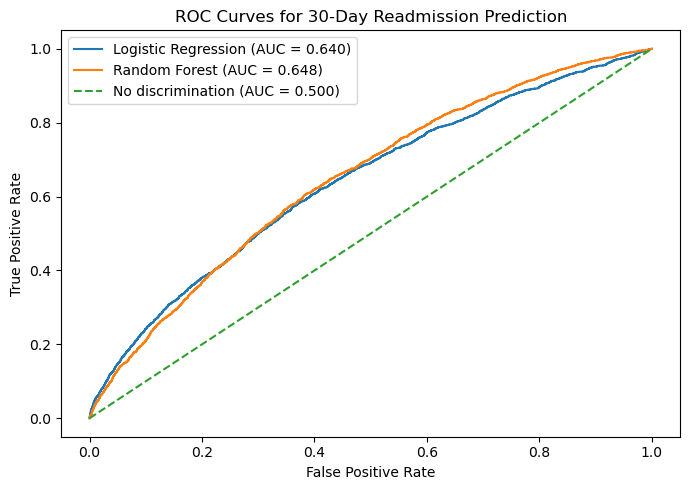

In [43]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(
    y_test_final,
    logistic_probs_final
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test_final,
    rf_probs_final
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_log,
    tpr_log,
    label="Logistic Regression (AUC = 0.640)"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest (AUC = 0.648)"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No discrimination (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for 30-Day Readmission Prediction")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

This project evaluated whether routinely collected clinical and hospitalization data could help identify patients with diabetes at increased risk of hospital readmission within 30 days.

The analysis included more than 100,000 hospital encounters after refinement of the study cohort.

Exploratory analysis identified a strong descriptive association between previous inpatient utilization and early readmission. The observed 30-day readmission rate increased from **8.44%** among encounters with no previous inpatient visits to **36.41%** among those with five or more previous inpatient visits.

A majority-class baseline achieved high accuracy but completely failed to identify readmitted patients, demonstrating the limitations of accuracy in an imbalanced clinical dataset.

Both Logistic Regression and Random Forest improved the identification of early readmissions. Random Forest achieved the highest recall (**59.36%**) and ROC-AUC (**0.648**), although precision remained low.

During model interpretation, discharge disposition emerged as an influential predictor. Clinical review of the data dictionary revealed that the original cohort included patients who had died and therefore could not subsequently be readmitted. These encounters were excluded and the complete modeling pipeline was retrained.

This iterative process highlights the importance of combining clinical reasoning with data science: predictive performance alone is not sufficient without careful cohort definition and evaluation of whether model features are clinically appropriate.

The final models should be considered exploratory risk-stratification models and are not suitable for clinical decision-making without further validation and methodological development.

## Limitations

- The dataset is retrospective and observational.
- Data were collected between 1999 and 2008 and may not reflect current clinical practice.
- The analysis is encounter-based and may include multiple encounters from the same patient.
- The train-test split was performed at the encounter level rather than the patient level, which may allow encounters from the same patient to appear in both sets.
- Several variables contain administrative codes rather than directly interpretable clinical measurements.
- Some potentially important variables, including weight, were excluded because of extensive missingness.
- Class imbalance resulted in relatively low precision despite the use of balanced class weights.
- Random Forest feature importance does not establish causality.
- No external validation was performed.
- Classification thresholds were not optimized for a specific clinical workflow.